<a href="https://colab.research.google.com/github/victorrp1502/grupo1_caixaverso/blob/Branch_Marcos/marcos2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Pergunta 6 - Porte da empresa e salário. Empresas grandes (L), médias (M) ou pequenas (S) pagam mais? A diferença é maior em algum nível de experiência específico?

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [17]:
def carregar_banco_csv(caminho):
    return pd.read_csv(caminho)
    pass

In [18]:
df = carregar_banco_csv('https://drive.google.com/uc?id=1k-6AbaByg4SWF9UgrJ94p4TafHHXOmUG')

In [19]:
df

,job_title,experience_level,employment_type,work_models,work_year,employee_residence,salary,salary_currency,salary_in_usd,company_location,company_size
0,Data Engineer,Mid-level,Full-time,Remote,2024,United States,148100,USD,148100,United States,Medium
1,Data Engineer,Mid-level,Full-time,Remote,2024,United States,98700,USD,98700,United States,Medium
2,Data Scientist,Senior-level,Full-time,Remote,2024,United States,140032,USD,140032,United States,Medium
3,Data Scientist,Senior-level,Full-time,Remote,2024,United States,100022,USD,100022,United States,Medium
4,BI Developer,Mid-level,Full-time,On-site,2024,United States,120000,USD,120000,United States,Medium
...,...,...,...,...,...,...,...,...,...,...,...
6594,Staff Data Analyst,Entry-level,Contract,Hybrid,2020,Canada,60000,CAD,44753,Canada,Large
6595,Staff Data Analyst,Executive-level,Full-time,On-site,2020,Nigeria,15000,USD,15000,Canada,Medium
6596,Machine Learning Manager,Senior-level,Full-time,Hybrid,2020,Canada,157000,CAD,117104,Canada,Large
6597,Data Engineer,Mid-level,Full-time,Hybrid,2020,Austria,65000,EUR,74130,Austria,Large


In [20]:
def media_salario_por_porte(df):
    return df.groupby('company_size')['salary_in_usd'].mean().round(2).reset_index().rename(columns={'company_size': 'Porte da Empresa',
              'salary_in_usd': 'Salário Médio'}).sort_values(by='Salário Médio', ascending=False)

In [21]:
media_salario_por_porte(df)

,Porte da Empresa,Salário Médio
1,Medium,149659.39
0,Large,120638.40
2,Small,87687.46


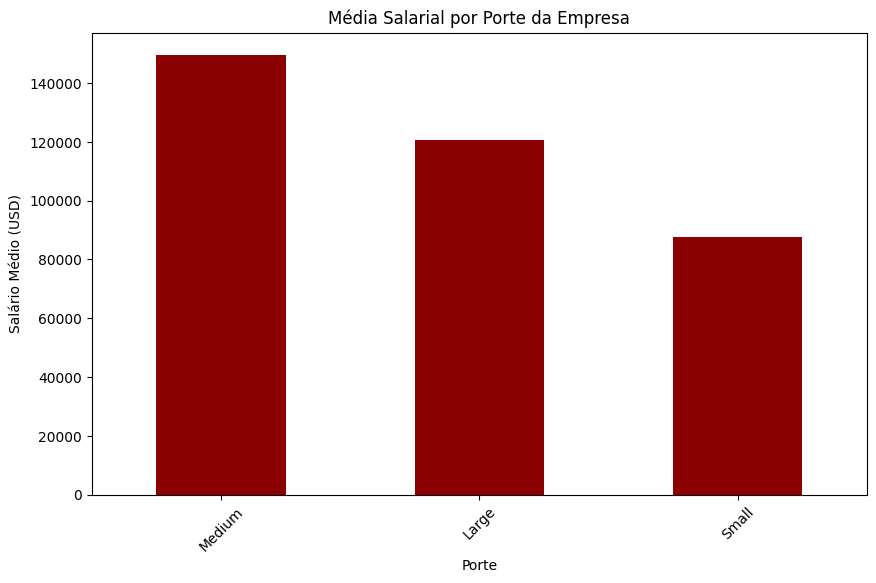

In [22]:
df_porte = media_salario_por_porte(df)

df_porte.plot(
    x='Porte da Empresa',
    y='Salário Médio',
    kind='bar',
    figsize=(10,6),
    legend=False,
    color='darkred'
)

plt.title('Média Salarial por Porte da Empresa')
plt.ylabel('Salário Médio (USD)')
plt.xlabel('Porte')
plt.xticks(rotation=45)
plt.show()

In [23]:
def media_salario_porte_por_experiencia(df):
    #top10_paises = (df.groupby('company_size')['salary_in_usd'].mean().round(2).reset_index()
          #.sort_values(by='salary_in_usd', ascending=False).head(10)['employee_residence'].tolist())

    #df_filtrado = df[df['employee_residence'].isin(top10_paises)]

    #return df_filtrado.groupby(['employee_residence', 'work_models'])['salary_in_usd']\
        #.mean().round(2).reset_index().rename(columns={'employee_residence': 'País',
        #'work_models': 'Modalidade','salary_in_usd': 'Salário Médio'}).sort_values(by=['País', 'Salário Médio'], ascending=[True, False])

  return df.groupby(['company_size', 'experience_level'])['salary_in_usd']\
        .mean().round(2).reset_index().rename(columns={'company_size': 'Porte',
        'experience_level': 'Experiência','salary_in_usd': 'Salário Médio'}).sort_values(by=['Porte', 'Experiência'], ascending=[True, True])


In [24]:
media_salario_porte_por_experiencia(df)

,Porte,Experiência,Salário Médio
0,Large,Entry-level,74603.33
1,Large,Executive-level,187993.90
2,Large,Mid-level,100625.17
3,Large,Senior-level,150556.66
4,Medium,Entry-level,89223.05
5,Medium,Executive-level,190563.40
6,Medium,Mid-level,123303.99
7,Medium,Senior-level,163532.47
8,Small,Entry-level,68485.94
9,Small,Executive-level,169172.38


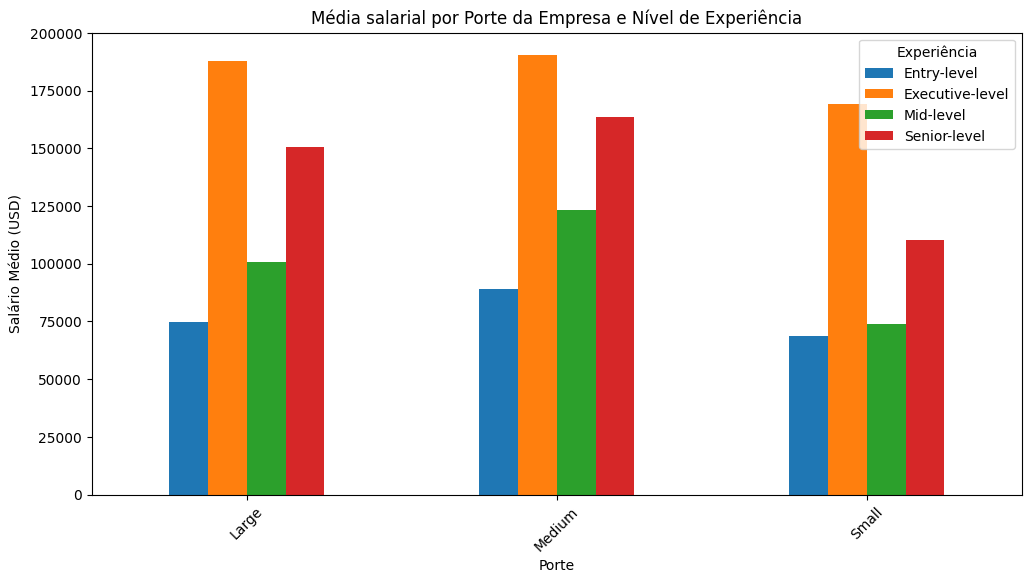

In [26]:
df_porte_experiencia = media_salario_porte_por_experiencia(df)

pivot = df_porte_experiencia.pivot(index='Porte', columns='Experiência', values='Salário Médio')

pivot.plot(kind='bar', figsize=(12,6))
plt.title('Média salarial por Porte da Empresa e Nível de Experiência')
plt.ylabel('Salário Médio (USD)')
plt.xlabel('Porte')
plt.xticks(rotation=45)
plt.legend(title='Experiência')
plt.show()

#Respondendo à pergunta:

- Considerando os maiores salários médios, as melhores oportunidades estão nos países: Israel, Qatar, Malásia, Porto Rico, Estados Unidos, Nova Zelândia, Canadá, Arábia Saudita, China e Bósnia e Herzegovina. Os valores vão de 417.937,00 - maior média - até 120.000,00.

- Analisando os países que possuem as maiores médias salariais, entre aqueles que oferecem mais de uma opção de modalidade de trabalho, não foram observadas diferenças marcantes entre as modalidades presencial e remota (Canadá com médias salariais de 142.655,21 e 142.192,41; EUA com 159.901,83 e 154.634,15, respectivamente); somente foi identificada uma tendência de menor remuneração para a modalidade híbrida, quando oferecida em conjunto com as demais - corresponde a 79% do valor médio para a presencial no Canadá, e a 88,4% nos EUA. Na Nova Zelândia, que não oferece opção de remoto, o híbrido tem remuneração média igual a 75,8% da modalidade presencial.